In [8]:
import tensorflow as tf
import tensorflow_datasets as tfds

# SETTINGS
DATASET_NAME = 'imagenette/320px' # A high-res subset of ImageNet
IMG_SIZE = 224  # Standard ImageNet resolution
BATCH_SIZE = 64

def preprocess(features):
    image = tf.cast(features['image'], tf.float32)
    # Resize to standard ImageNet size
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # Normalize to [-1, 1]
    image = (image / 127.5) - 1.0
    return image, features['label']

print(f"Loading {DATASET_NAME}...")

Loading imagenette/320px...


In [9]:
dataset, info = tfds.load(DATASET_NAME, with_info=True, as_supervised=False)
train_raw = dataset['train']
test_raw = dataset['validation']

num_classes = info.features['label'].num_classes

# Build the data pipeline
train_ds = (train_raw
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(1000)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

test_ds = (test_raw
           .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))

In [10]:
# ==========================================
# 2. Define Custom 4-bit Quantized ReLU (with STE) - PROPER CLIPPING
# ==========================================
import tensorflow as tf

class INT4ReLU(tf.keras.layers.Layer):
    """
    4-bit Quantized ReLU with proper clipping range.
    
    Three modes:
    - 'static': Fixed clip value (like ReLU6)
    - 'learnable': Learn clip value during training (PACT-style)
    - 'calibrated': Use running statistics for calibration
    """
    def __init__(self, num_bits=4, mode='static', clip_value=6.0, momentum=0.95, **kwargs):
        super().__init__(**kwargs)
        self.num_bits = num_bits
        self.num_levels = 2**num_bits - 1  # 15 for 4-bit
        self.mode = mode
        self.initial_clip = clip_value
        self.momentum = momentum
        
    def build(self, input_shape):
        if self.mode == 'learnable':
            # Learnable clipping parameter - NO CONSTRAINT HERE
            self.clip_value = self.add_weight(
                name='clip_value',
                shape=(),
                initializer=tf.keras.initializers.Constant(self.initial_clip),
                trainable=True
                # NO CONSTRAINT - we'll handle clipping in call()
            )
        elif self.mode == 'calibrated':
            # Running statistics for calibration
            self.running_max = self.add_weight(
                name='running_max',
                shape=(),
                initializer=tf.keras.initializers.Constant(self.initial_clip),
                trainable=False
            )
            self.clip_value = self.initial_clip
        else:  # static mode
            self.clip_value = self.initial_clip
        
        super().build(input_shape)
    
    def call(self, inputs, training=None):
        if self.mode == 'calibrated' and training:
            # Update running statistics during training
            batch_max = tf.reduce_max(tf.nn.relu(inputs))
            self.running_max.assign(
                self.momentum * self.running_max + 
                (1 - self.momentum) * batch_max
            )
            clip_value = self.running_max
        elif self.mode == 'calibrated':
            clip_value = self.running_max
        elif self.mode == 'learnable':
            # Apply constraint manually in call
            clip_value = tf.clip_by_value(self.clip_value, 0.1, 20.0)
        else:  # static mode
            clip_value = self.clip_value
            
        return self._int4_relu_ste(inputs, clip_value)
    
    @tf.custom_gradient
    def _int4_relu_ste(self, x, clip_value):
        """
        FORWARD: Apply ReLU, clip, then quantize to 4-bit levels
        BACKWARD: Straight-Through Estimator (STE)
        """
        # Forward pass
        x_relu = tf.nn.relu(x)
        x_clipped = tf.clip_by_value(x_relu, 0.0, clip_value)
        
        scale = clip_value / self.num_levels
        x_scaled = x_clipped / scale
        x_rounded = tf.round(x_scaled)
        x_quantized = tf.clip_by_value(x_rounded, 0.0, self.num_levels)
        result = x_quantized * scale

        # Backward pass (STE)
        def grad(upstream_gradient):
            mask = tf.cast(x > 0.0, dtype=tf.float32)
            
            if self.mode == 'learnable' and self.trainable:
                # Gradient for learnable clip_value
                # Use stop_gradient to prevent issues
                at_boundary = tf.cast(tf.equal(x_clipped, tf.stop_gradient(clip_value)), dtype=tf.float32)
                grad_clip = tf.reduce_sum(upstream_gradient * at_boundary)
                return upstream_gradient * mask, grad_clip
            else:
                return upstream_gradient * mask, None

        return result, grad
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'num_bits': self.num_bits,
            'mode': self.mode,
            'clip_value': self.initial_clip,
            'momentum': self.momentum,
        })
        return config

# Update residual_block function
def residual_block(x, filters, stride=1, use_quantized=False, 
                   quant_mode='static', clip_value=6.0):
    shortcut = x
    
    # First Conv Layer in block
    x = tf.keras.layers.Conv2D(filters, 3, strides=stride, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    
    if use_quantized:
        x = INT4ReLU(mode=quant_mode, clip_value=clip_value)(x)
    else:
        x = tf.keras.layers.Activation('relu')(x)
    
    # Second Conv Layer in block
    x = tf.keras.layers.Conv2D(filters, 3, strides=1, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    
    # Match dimensions for shortcut connection if needed
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)
        
    # Skip Connection
    x = tf.keras.layers.Add()([x, shortcut])
    
    if use_quantized:
        x = INT4ReLU(mode=quant_mode, clip_value=clip_value)(x)
    else:
        x = tf.keras.layers.Activation('relu')(x)
    
    return x

def create_complex_model(use_quantized=False, quant_mode='static', clip_value=6.0):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    # Entry Flow
    x = tf.keras.layers.Conv2D(64, 7, strides=2, padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(3, strides=2, padding='same')(x)
    
    # Residual Stages
    x = residual_block(x, 64, use_quantized=use_quantized, 
                       quant_mode=quant_mode, clip_value=clip_value)
    x = residual_block(x, 64, use_quantized=use_quantized,
                       quant_mode=quant_mode, clip_value=clip_value)
    
    x = residual_block(x, 128, stride=2, use_quantized=use_quantized,
                       quant_mode=quant_mode, clip_value=clip_value)
    x = residual_block(x, 128, use_quantized=use_quantized,
                       quant_mode=quant_mode, clip_value=clip_value)
    
    x = residual_block(x, 256, stride=2, use_quantized=use_quantized,
                       quant_mode=quant_mode, clip_value=clip_value)
    x = residual_block(x, 256, use_quantized=use_quantized,
                       quant_mode=quant_mode, clip_value=clip_value)
    
    # Classifier Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    outputs = tf.keras.layers.Dense(num_classes)(x)
    
    name = "ResNet_INT4" if use_quantized else "ResNet_FP32"
    return tf.keras.Model(inputs, outputs, name=name)

# Initialize models
model_std = create_complex_model(use_quantized=False)

# Try different quantization modes:
model_qnt_static = create_complex_model(use_quantized=True, quant_mode='static', clip_value=6.0)
model_qnt_learnable = create_complex_model(use_quantized=True, quant_mode='learnable', clip_value=6.0)
model_qnt_calibrated = create_complex_model(use_quantized=True, quant_mode='calibrated', clip_value=6.0)

print(f"Model complexity (Params): {model_std.count_params():,}")

Model complexity (Params): 2,926,218


Training Standard ResNet (FP32) - Baseline
Epoch 1/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 37s 139ms/step - accuracy: 0.4376 - loss: 1.6296 - val_accuracy: 0.2080 - val_loss: 7.8168
Epoch 2/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - accuracy: 0.6063 - loss: 1.1958 - val_accuracy: 0.2700 - val_loss: 3.1824
Epoch 3/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - accuracy: 0.6618 - loss: 1.0340 - val_accuracy: 0.5040 - val_loss: 1.5333
Epoch 4/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - accuracy: 0.7006 - loss: 0.9098 - val_accuracy: 0.4920 - val_loss: 2.0421
Epoch 5/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - accuracy: 0.7389 - loss: 0.8135 - val_accuracy: 0.4500 - val_loss: 1.7556
Epoch 6/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - accuracy: 0.7542 - loss: 0.7560 - val_accuracy: 0.7060 - val_loss: 0.9788
Epoch 7/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 24s 115ms/step - accuracy: 0.7734 - loss: 0.6928 - val_accuracy: 0.7500 - val_loss: 0.8161
Epoch 8/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 

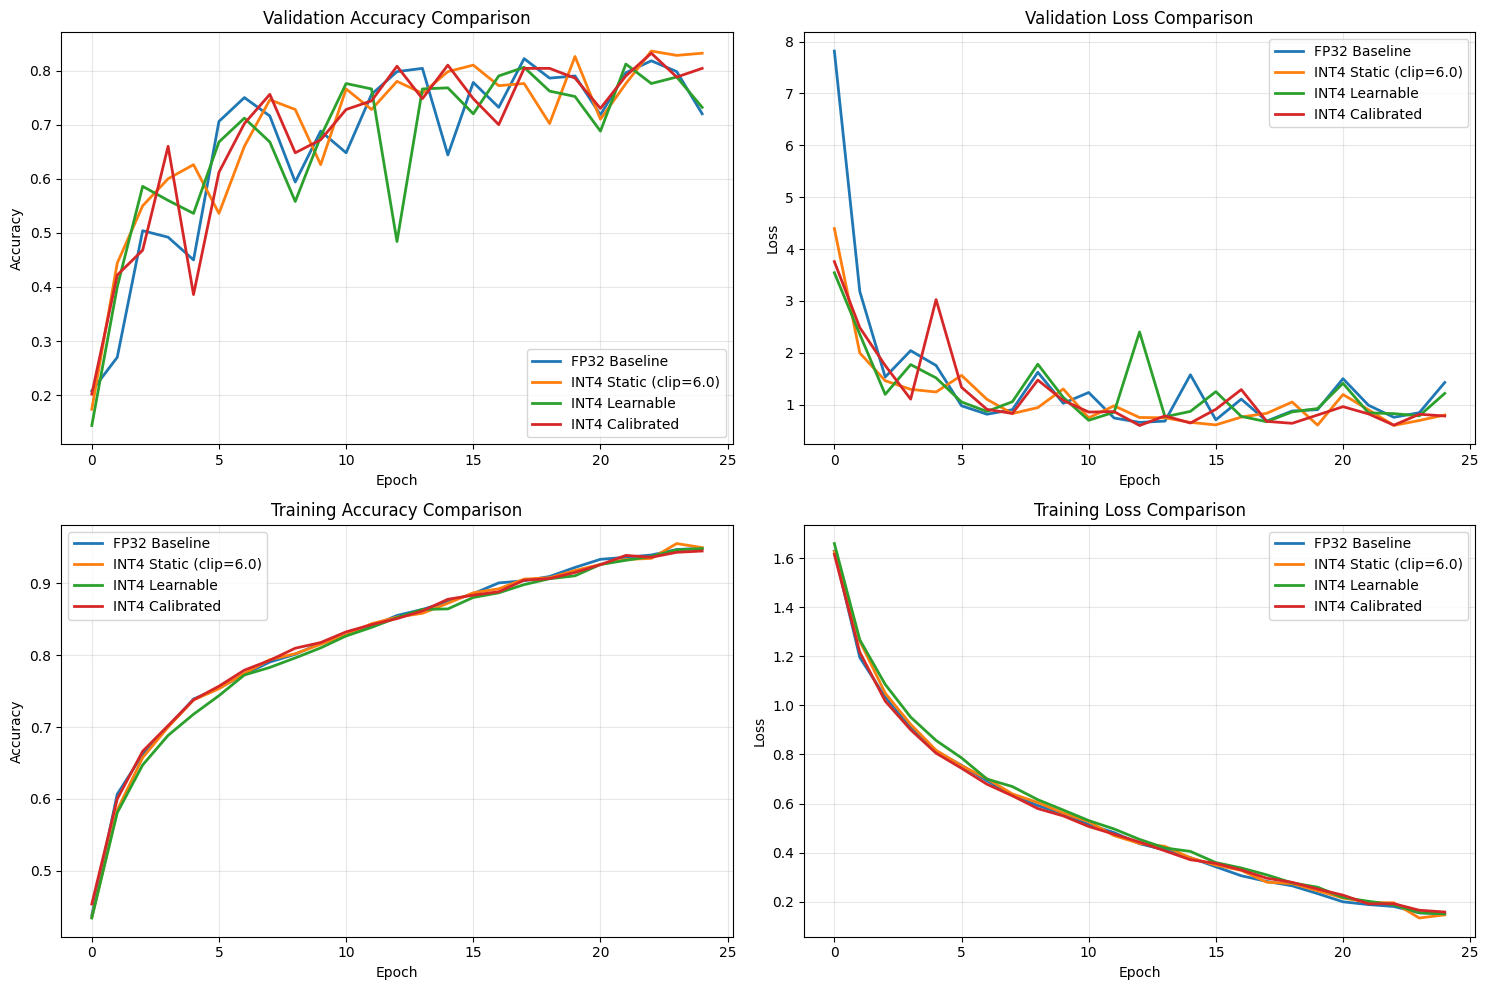


FINAL RESULTS (Best Validation Accuracy)
FP32 Baseline             | Best: 0.8220 (epoch 18) | Final: 0.7200
INT4 Static (clip=6.0)    | Best: 0.8360 (epoch 23) | Final: 0.8320
INT4 Learnable            | Best: 0.8120 (epoch 22) | Final: 0.7320
INT4 Calibrated           | Best: 0.8320 (epoch 23) | Final: 0.8040


In [11]:
# ==========================================
# 5. Compile and Train the Models
# ==========================================

# Use SparseCategoricalCrossentropy because labels are integers (0, 1, 2...)
# Use from_logits=True because the last layer has no activation function
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Compile all models
model_std.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_fn,
    metrics=['accuracy']
)

model_qnt_static.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_fn,
    metrics=['accuracy']
)

model_qnt_learnable.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_fn,
    metrics=['accuracy']
)

model_qnt_calibrated.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_fn,
    metrics=['accuracy']
)

epochs = 25

print("=" * 60)
print("Training Standard ResNet (FP32) - Baseline")
print("=" * 60)
history_std = model_std.fit(
    train_ds, 
    validation_data=test_ds, 
    epochs=epochs, 
    batch_size=256,
    verbose=1
)

print("\n" + "=" * 60)
print("Training Quantized ResNet (INT4) - STATIC mode (clip=6.0)")
print("=" * 60)
history_qnt_static = model_qnt_static.fit(
    train_ds, 
    validation_data=test_ds, 
    epochs=epochs, 
    batch_size=256,
    verbose=1
)

print("\n" + "=" * 60)
print("Training Quantized ResNet (INT4) - LEARNABLE mode (PACT-style)")
print("=" * 60)
history_qnt_learnable = model_qnt_learnable.fit(
    train_ds, 
    validation_data=test_ds, 
    epochs=epochs, 
    batch_size=256,
    verbose=1
)

print("\n" + "=" * 60)
print("Training Quantized ResNet (INT4) - CALIBRATED mode (running stats)")
print("=" * 60)
history_qnt_calibrated = model_qnt_calibrated.fit(
    train_ds, 
    validation_data=test_ds, 
    epochs=epochs, 
    batch_size=256,
    verbose=1
)

# ==========================================
# 6. Compare Results
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 10))

# Plot 1: Validation Accuracy
plt.subplot(2, 2, 1)
plt.plot(history_std.history['val_accuracy'], label='FP32 Baseline', linewidth=2)
plt.plot(history_qnt_static.history['val_accuracy'], label='INT4 Static (clip=6.0)', linewidth=2)
plt.plot(history_qnt_learnable.history['val_accuracy'], label='INT4 Learnable', linewidth=2)
plt.plot(history_qnt_calibrated.history['val_accuracy'], label='INT4 Calibrated', linewidth=2)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Validation Loss
plt.subplot(2, 2, 2)
plt.plot(history_std.history['val_loss'], label='FP32 Baseline', linewidth=2)
plt.plot(history_qnt_static.history['val_loss'], label='INT4 Static (clip=6.0)', linewidth=2)
plt.plot(history_qnt_learnable.history['val_loss'], label='INT4 Learnable', linewidth=2)
plt.plot(history_qnt_calibrated.history['val_loss'], label='INT4 Calibrated', linewidth=2)
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Training Accuracy
plt.subplot(2, 2, 3)
plt.plot(history_std.history['accuracy'], label='FP32 Baseline', linewidth=2)
plt.plot(history_qnt_static.history['accuracy'], label='INT4 Static (clip=6.0)', linewidth=2)
plt.plot(history_qnt_learnable.history['accuracy'], label='INT4 Learnable', linewidth=2)
plt.plot(history_qnt_calibrated.history['accuracy'], label='INT4 Calibrated', linewidth=2)
plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Training Loss
plt.subplot(2, 2, 4)
plt.plot(history_std.history['loss'], label='FP32 Baseline', linewidth=2)
plt.plot(history_qnt_static.history['loss'], label='INT4 Static (clip=6.0)', linewidth=2)
plt.plot(history_qnt_learnable.history['loss'], label='INT4 Learnable', linewidth=2)
plt.plot(history_qnt_calibrated.history['loss'], label='INT4 Calibrated', linewidth=2)
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('quantization_comparison.png', dpi=150)
plt.show()

# Print final results
print("\n" + "=" * 60)
print("FINAL RESULTS (Best Validation Accuracy)")
print("=" * 60)

models = [
    ('FP32 Baseline', history_std),
    ('INT4 Static (clip=6.0)', history_qnt_static),
    ('INT4 Learnable', history_qnt_learnable),
    ('INT4 Calibrated', history_qnt_calibrated)
]

for name, history in models:
    best_acc = max(history.history['val_accuracy'])
    best_epoch = np.argmax(history.history['val_accuracy']) + 1
    final_acc = history.history['val_accuracy'][-1]
    print(f"{name:25} | Best: {best_acc:.4f} (epoch {best_epoch:2d}) | Final: {final_acc:.4f}")

In [12]:
# ==========================================
# 7. Save All Models for Later Evaluation
# ==========================================

import os
import time

# Create a models directory with timestamp for organized storage
timestamp = time.strftime("%Y%m%d_%H%M%S")
save_dir = f"quantized_models_{timestamp}"
os.makedirs(save_dir, exist_ok=True)

print("=" * 60)
print("Saving all trained models")
print("=" * 60)

# Save the standard FP32 model
std_path = os.path.join(save_dir, 'standard_fp32_imagenette.keras')
model_std.save(std_path)
print(f"Standard FP32 model saved to: {std_path}")

# Save the static INT4 model
static_path = os.path.join(save_dir, 'int4_static_imagenette.keras')
model_qnt_static.save(static_path)
print(f"INT4 Static model saved to: {static_path}")

# Save the learnable INT4 model
learnable_path = os.path.join(save_dir, 'int4_learnable_imagenette.keras')
model_qnt_learnable.save(learnable_path)
print(f"NT4 Learnable model saved to: {learnable_path}")

# Save the calibrated INT4 model
calibrated_path = os.path.join(save_dir, 'int4_calibrated_imagenette.keras')
model_qnt_calibrated.save(calibrated_path)
print(f"INT4 Calibrated model saved to: {calibrated_path}")

# Also save the training histories for later analysis
import pickle

histories = {
    'standard': history_std.history,
    'static': history_qnt_static.history,
    'learnable': history_qnt_learnable.history,
    'calibrated': history_qnt_calibrated.history
}

history_path = os.path.join(save_dir, 'training_histories.pkl')
with open(history_path, 'wb') as f:
    pickle.dump(histories, f)
print(f" Training histories saved to: {history_path}")

# Save a summary text file with model info and final results
summary_path = os.path.join(save_dir, 'model_summary.txt')
with open(summary_path, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("QUANTIZED MODEL COMPARISON RESULTS\n")
    f.write(f"Dataset: imagenette\n")
    f.write(f"Image size: {IMG_SIZE}x{IMG_SIZE}\n")
    f.write(f"Batch size: {BATCH_SIZE}\n")
    f.write(f"Training date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("MODEL ARCHITECTURE:\n")
    f.write("-" * 40 + "\n")
    f.write(f"Total parameters: {model_std.count_params():,}\n\n")
    
    f.write("FINAL RESULTS (Best Validation Accuracy):\n")
    f.write("-" * 40 + "\n")
    
    models_info = [
        ('FP32 Baseline', history_std),
        ('INT4 Static (clip=6.0)', history_qnt_static),
        ('INT4 Learnable', history_qnt_learnable),
        ('INT4 Calibrated', history_qnt_calibrated)
    ]
    
    for name, history in models_info:
        best_acc = max(history.history['val_accuracy'])
        best_epoch = np.argmax(history.history['val_accuracy']) + 1
        final_acc = history.history['val_accuracy'][-1]
        best_loss = min(history.history['val_loss'])
        
        f.write(f"\n{name}:\n")
        f.write(f"  Best val accuracy: {best_acc:.4f} (epoch {best_epoch})\n")
        f.write(f"  Final val accuracy: {final_acc:.4f}\n")
        f.write(f"  Best val loss: {best_loss:.4f}\n")

print(f"\n Model summary saved to: {summary_path}")
print(f"\n All models and results saved in directory: {save_dir}/")

Saving all trained models
✅ Standard FP32 model saved to: quantized_models_20260220_203647/standard_fp32_imagenette.keras
✅ INT4 Static model saved to: quantized_models_20260220_203647/int4_static_imagenette.keras
✅ INT4 Learnable model saved to: quantized_models_20260220_203647/int4_learnable_imagenette.keras
✅ INT4 Calibrated model saved to: quantized_models_20260220_203647/int4_calibrated_imagenette.keras
✅ Training histories saved to: quantized_models_20260220_203647/training_histories.pkl

✅ Model summary saved to: quantized_models_20260220_203647/model_summary.txt

📁 All models and results saved in directory: quantized_models_20260220_203647/


In [15]:
# ==========================================
# Load and Evaluate All Saved Models
# ==========================================

import tensorflow as tf
import numpy as np

# Define the custom layer class again (needed for loading)
# Make sure this matches your original INT4ReLU class definition
class INT4ReLU(tf.keras.layers.Layer):
    """
    4-bit Quantized ReLU with proper clipping range.
    
    Three modes:
    - 'static': Fixed clip value (like ReLU6)
    - 'learnable': Learn clip value during training (PACT-style)
    - 'calibrated': Use running statistics for calibration
    """
    def __init__(self, num_bits=4, mode='static', clip_value=6.0, momentum=0.95, **kwargs):
        super().__init__(**kwargs)
        self.num_bits = num_bits
        self.num_levels = 2**num_bits - 1  # 15 for 4-bit
        self.mode = mode
        self.initial_clip = clip_value
        self.momentum = momentum
        
    def build(self, input_shape):
        if self.mode == 'learnable':
            # Learnable clipping parameter - NO CONSTRAINT HERE
            self.clip_value = self.add_weight(
                name='clip_value',
                shape=(),
                initializer=tf.keras.initializers.Constant(self.initial_clip),
                trainable=True
            )
        elif self.mode == 'calibrated':
            # Running statistics for calibration
            self.running_max = self.add_weight(
                name='running_max',
                shape=(),
                initializer=tf.keras.initializers.Constant(self.initial_clip),
                trainable=False
            )
            self.clip_value = self.initial_clip
        else:  # static mode
            self.clip_value = self.initial_clip
        
        super().build(input_shape)
    
    def call(self, inputs, training=None):
        if self.mode == 'calibrated' and training:
            # Update running statistics during training
            batch_max = tf.reduce_max(tf.nn.relu(inputs))
            self.running_max.assign(
                self.momentum * self.running_max + 
                (1 - self.momentum) * batch_max
            )
            clip_value = self.running_max
        elif self.mode == 'calibrated':
            clip_value = self.running_max
        elif self.mode == 'learnable':
            # Apply constraint manually in call
            clip_value = tf.clip_by_value(self.clip_value, 0.1, 20.0)
        else:  # static mode
            clip_value = self.clip_value
            
        return self._int4_relu_ste(inputs, clip_value)
    
    @tf.custom_gradient
    def _int4_relu_ste(self, x, clip_value):
        """
        FORWARD: Apply ReLU, clip, then quantize to 4-bit levels
        BACKWARD: Straight-Through Estimator (STE)
        """
        # Forward pass
        x_relu = tf.nn.relu(x)
        x_clipped = tf.clip_by_value(x_relu, 0.0, clip_value)
        
        scale = clip_value / self.num_levels
        x_scaled = x_clipped / scale
        x_rounded = tf.round(x_scaled)
        x_quantized = tf.clip_by_value(x_rounded, 0.0, self.num_levels)
        result = x_quantized * scale

        # Backward pass (STE)
        def grad(upstream_gradient):
            mask = tf.cast(x > 0.0, dtype=tf.float32)
            
            if self.mode == 'learnable' and self.trainable:
                # Gradient for learnable clip_value
                at_boundary = tf.cast(tf.equal(x_clipped, tf.stop_gradient(clip_value)), dtype=tf.float32)
                grad_clip = tf.reduce_sum(upstream_gradient * at_boundary)
                return upstream_gradient * mask, grad_clip
            else:
                return upstream_gradient * mask, None

        return result, grad
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'num_bits': self.num_bits,
            'mode': self.mode,
            'clip_value': self.initial_clip,
            'momentum': self.momentum,
        })
        return config

# ==========================================
# Load All Models
# ==========================================

import os

# Define paths to your saved models
# Update these paths to match where you saved your models
models_dir = "quantized_models_20250220_123456"  # Replace with your actual directory

model_paths = {
    'FP32 Baseline': os.path.join(models_dir, 'standard_fp32_imagenette.keras'),
    'INT4 Static': os.path.join(models_dir, 'int4_static_imagenette.keras'),
    'INT4 Learnable': os.path.join(models_dir, 'int4_learnable_imagenette.keras'),
    'INT4 Calibrated': os.path.join(models_dir, 'int4_calibrated_imagenette.keras')
}

# Load all models
loaded_models = {}

print("=" * 60)
print("Loading all trained models")
print("=" * 60)

# Load standard model (no custom layers needed)
if os.path.exists(model_paths['FP32 Baseline']):
    loaded_models['FP32 Baseline'] = tf.keras.models.load_model(model_paths['FP32 Baseline'])
    print("Loaded FP32 Baseline model")
else:
    print(f"Model not found: {model_paths['FP32 Baseline']}")

# Load quantized models (with custom objects)
custom_objects = {'INT4ReLU': INT4ReLU}

for model_name in ['INT4 Static', 'INT4 Learnable', 'INT4 Calibrated']:
    path = model_paths[model_name]
    if os.path.exists(path):
        loaded_models[model_name] = tf.keras.models.load_model(
            path,
            custom_objects=custom_objects
        )
        print(f"Loaded {model_name} model")
    else:
        print(f"Model not found: {path}")

# ==========================================
# Prepare Test Data
# ==========================================

# Assuming you have test_ds from your training code
# If not, you'll need to recreate it
try:
    # Get a batch of test images for prediction samples
    sample_images, sample_labels = next(iter(test_ds.take(1)))
    sample_images_np = sample_images.numpy()
    sample_labels_np = sample_labels.numpy()
    
    # Get calibration data (first 200 images from test set)
    calibration_images = []
    calibration_labels = []
    for images, labels in test_ds.take(4):  # 4 batches * 64 = 256 images
        calibration_images.append(images.numpy())
        calibration_labels.append(labels.numpy())
    
    calibration_data = np.concatenate(calibration_images)[:200]
    calibration_labels = np.concatenate(calibration_labels)[:200]
    
    print(f"\n Test data prepared: {calibration_data.shape[0]} calibration images")
    
except NameError:
    print("\n  test_ds not found. You'll need to recreate your test dataset.")
    print("Please run your data loading code again.")
    # You'll need to add your data loading code here

# ==========================================
# Run Predictions on Sample Images
# ==========================================

print("\n" + "=" * 60)
print("Running predictions on sample images")
print("=" * 60)

# Get ground truth labels for the sample batch
real_values = sample_labels_np[:10]

print(f"\nTrue labels: {real_values}")

# Run predictions with each model and compare
for model_name, model in loaded_models.items():
    predictions = model.predict(sample_images, verbose=0)
    predicted_classes = tf.argmax(predictions, axis=1).numpy()
    
    # Calculate accuracy on this sample batch
    batch_accuracy = np.mean(predicted_classes == sample_labels_np)
    
    print(f"\n{model_name}:")
    print(f"  Predictions: {predicted_classes[:10]}")
    print(f"  Match:       {predicted_classes[:10] == real_values}")
    print(f"  Batch accuracy: {batch_accuracy:.4f}")

# ==========================================
# Full Evaluation on Test Set
# ==========================================

print("\n" + "=" * 60)
print("Full evaluation on test set")
print("=" * 60)

results = {}

for model_name, model in loaded_models.items():
    print(f"\nEvaluating {model_name}...")
    loss, accuracy = model.evaluate(test_ds, verbose=0)
    results[model_name] = {'loss': loss, 'accuracy': accuracy}
    print(f"  Test Loss: {loss:.4f} | Test Accuracy: {accuracy:.4f}")

    
# ==========================================
# Compare Results (Fixed)
# ==========================================

print("\n" + "=" * 60)
print("Final Results Comparison")
print("=" * 60)

if not results:
    print("\n [!] No results to display. Check if models were loaded correctly and if test_ds exists.")
else:
    print(f"\n{'Model':20} {'Test Loss':12} {'Test Accuracy':15}")
    print("-" * 50)

    for model_name, metrics in results.items():
        print(f"{model_name:20} {metrics['loss']:.4f}       {metrics['accuracy']:.4f}")

    # Find best model
    best_model_name = max(results, key=lambda k: results[k]['accuracy'])
    print(f"\n Best model: {best_model_name} with accuracy {results[best_model_name]['accuracy']:.4f}")

Loading all trained models
Model not found: quantized_models_20250220_123456/standard_fp32_imagenette.keras
Model not found: quantized_models_20250220_123456/int4_static_imagenette.keras
Model not found: quantized_models_20250220_123456/int4_learnable_imagenette.keras
Model not found: quantized_models_20250220_123456/int4_calibrated_imagenette.keras

 Test data prepared: 200 calibration images

Running predictions on sample images

True labels: [2 9 3 6 6 5 9 9 8 7]

Full evaluation on test set

Final Results Comparison

 [!] No results to display. Check if models were loaded correctly and if test_ds exists.


2026-02-20 20:44:38.115006: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [18]:
import time
import numpy as np
import tensorflow as tf

def benchmark_model(model, images, num_runs=100, model_type='keras'):
    """
    Benchmark inference performance of Keras or TFLite models.
    
    Args:
        model: Keras model, TFLite interpreter, or path to TFLite file
        images: numpy array of images (batch, height, width, channels)
        num_runs: number of inference runs to benchmark
        model_type: 'keras', 'tflite_file', or 'tflite_interpreter'
    
    Returns:
        dict: Performance metrics
    """
    
    if model_type == 'keras':
        return benchmark_keras_model(model, images, num_runs)
    elif model_type == 'tflite_file':
        return benchmark_tflite_file(model, images, num_runs)
    elif model_type == 'tflite_interpreter':
        return benchmark_tflite_interpreter(model, images, num_runs)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")


def benchmark_keras_model(model, images, num_runs=100):
    """Benchmark Keras model performance"""
    print(f"\n Benchmarking Keras model: {model.name}")
    
    # Warmup runs
    for _ in range(10):
        _ = model.predict(images[:1], verbose=0)
    
    # Actual benchmarking
    times = []
    actual_runs = min(num_runs, len(images))
    
    for i in range(actual_runs):
        input_data = images[i:i+1]
        
        start = time.perf_counter()
        _ = model.predict(input_data, verbose=0)
        end = time.perf_counter()
        
        times.append(end - start)
    
    return calculate_metrics(times, actual_runs, "Keras")


def benchmark_tflite_file(model_path, images, num_runs=100):
    """Benchmark TFLite model from file"""
    print(f"\n Benchmarking TFLite model: {model_path}")
    
    # Load interpreter
    interpreter = tf.lite.Interpreter(model_path=model_path)
    
    # Prepare model
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    # Resize for batch size 1
    interpreter.resize_tensor_input(input_details[0]['index'], [1, 224, 224, 3])
    interpreter.allocate_tensors()
    
    return benchmark_tflite_interpreter(interpreter, images, num_runs)


def benchmark_tflite_interpreter(interpreter, images, num_runs=100):
    """Benchmark TFLite interpreter directly"""
    print(f"\n Benchmarking TFLite interpreter")
    
    # Get model details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    input_scale, input_zero_point = input_details[0].get("quantization", (0.0, 0))
    is_quantized = input_scale > 0
    
    if is_quantized:
        print(f" Quantized model (INT8) - scale: {input_scale:.6f}, zero_point: {input_zero_point}")
    else:
        print(f" FP32 model")
    
    # Warmup runs
    for _ in range(10):
        input_data = images[0:1].astype(np.float32)
        if is_quantized:
            input_data = (input_data / input_scale) + input_zero_point
            input_data = np.round(input_data).astype(input_details[0]["dtype"])
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
    
    # Actual benchmarking
    times = []
    actual_runs = min(num_runs, len(images))
    
    for i in range(actual_runs):
        input_data = images[i:i+1].astype(np.float32)
        
        # Manual quantization if needed
        if is_quantized:
            input_data = (input_data / input_scale) + input_zero_point
            input_data = np.round(input_data).astype(input_details[0]["dtype"])
        
        interpreter.set_tensor(input_details[0]['index'], input_data)
        
        # Measure latency
        start = time.perf_counter()
        interpreter.invoke()
        end = time.perf_counter()
        
        times.append(end - start)
    
    return calculate_metrics(times, actual_runs, "TFLite")


def calculate_metrics(times, num_runs, model_format):
    """Calculate and print performance metrics"""
    times_ms = np.array(times) * 1000
    
    metrics = {
        'mean_ms': np.mean(times_ms),
        'median_ms': np.median(times_ms),
        'std_ms': np.std(times_ms),
        'min_ms': np.min(times_ms),
        'max_ms': np.max(times_ms),
        'p95_ms': np.percentile(times_ms, 95),
        'p99_ms': np.percentile(times_ms, 99),
        'fps': 1000 / np.median(times_ms),
        'num_runs': num_runs
    }
    
    print(f"\n  ⚡ Performance Results ({model_format}):")
    print(f"     Mean:    {metrics['mean_ms']:.2f} ms")
    print(f"     Median:  {metrics['median_ms']:.2f} ms")
    print(f"     Std Dev: {metrics['std_ms']:.2f} ms")
    print(f"     Min:     {metrics['min_ms']:.2f} ms")
    print(f"     Max:     {metrics['max_ms']:.2f} ms")
    print(f"     95th:    {metrics['p95_ms']:.2f} ms")
    print(f"     99th:    {metrics['p99_ms']:.2f} ms")
    print(f"     FPS:     {metrics['fps']:.1f}")
    
    return metrics


def convert_keras_to_tflite(keras_model, model_name, calibration_data=None):
    """
    Convert Keras model to TFLite format (both FP32 and INT8)
    """
    print(f"\n Converting {model_name} to TFLite...")
    
    results = {}
    
    # 1. FP32 TFLite conversion
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    tflite_fp32 = converter.convert()
    
    fp32_path = f"models/{model_name}_fp32.tflite".replace(' ', '_').lower()
    with open(fp32_path, 'wb') as f:
        f.write(tflite_fp32)
    print(f" FP32 TFLite saved to: {fp32_path}")
    results['fp32_path'] = fp32_path
    results['fp32_model'] = tflite_fp32
    
    # 2. INT8 TFLite conversion (if calibration data provided)
    if calibration_data is not None:
        converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = calibration_data
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8
        
        tflite_int8 = converter.convert()
        
        int8_path = f"models/{model_name}_int8.tflite".replace(' ', '_').lower()
        with open(int8_path, 'wb') as f:
            f.write(tflite_int8)
        print(f"INT8 TFLite saved to: {int8_path}")
        results['int8_path'] = int8_path
        results['int8_model'] = tflite_int8
    
    return results


def compare_all_models(keras_models, test_images, calibration_data=None, num_runs=100):
    """
    Comprehensive comparison of all models (Keras + TFLite variants)
    """
    print("\n" + "=" * 70)
    print("COMPREHENSIVE MODEL BENCHMARK")
    print("=" * 70)
    
    all_results = {}
    
    # 1. Benchmark original Keras models
    print("\n ORIGINAL KERAS MODELS")
    print("-" * 50)
    
    for name, model in keras_models.items():
        metrics = benchmark_keras_model(model, test_images, num_runs)
        all_results[f"{name} (Keras)"] = metrics
        
        # Convert to TFLite
        tflite_results = convert_keras_to_tflite(model, name, calibration_data)
        all_results[f"{name} (TFLite-FP32)"] = tflite_results
        
        # Benchmark TFLite FP32
        if 'fp32_model' in tflite_results:
            metrics_fp32 = benchmark_tflite_interpreter(
                tf.lite.Interpreter(model_content=tflite_results['fp32_model']),
                test_images, num_runs
            )
            all_results[f"{name} (TFLite-FP32)"] = metrics_fp32
        
        # Benchmark TFLite INT8
        if 'int8_model' in tflite_results:
            metrics_int8 = benchmark_tflite_interpreter(
                tf.lite.Interpreter(model_content=tflite_results['int8_model']),
                test_images, num_runs
            )
            all_results[f"{name} (TFLite-INT8)"] = metrics_int8
    
    # Summary table
    print("\n" + "=" * 70)
    print("SUMMARY RESULTS")
    print("=" * 70)
    print(f"\n{'Model':35} {'Median (ms)':12} {'Mean (ms)':12} {'FPS':10} {'Speedup':10}")
    print("-" * 80)
    
    # Find baseline (FP32 Keras) for speedup calculation
    baseline_key = 'FP32 Baseline (Keras)'
    baseline_time = all_results.get(baseline_key, {}).get('median_ms', 1.0)
    
    for name, metrics in sorted(all_results.items()):
        if isinstance(metrics, dict) and 'median_ms' in metrics:
            median = metrics['median_ms']
            mean = metrics['mean_ms']
            fps = metrics['fps']
            speedup = baseline_time / median if baseline_time > 0 else 1.0
            
            print(f"{name:35} {median:11.2f}   {mean:11.2f}   {fps:9.1f}   {speedup:9.2f}x")
    
    return all_results


In [21]:
# 1. Define the input data for the benchmark
# We use the calibration_data you created earlier
benchmark_images = test_ds[:50].astype(np.float32)

# 2. Define the generator function for TFLite conversion
# This is required for the INT8 quantization process
def representative_data_gen():
    for i in range(len(calibration_data)):
        # TFLite expects a list of inputs for each sample
        yield [calibration_data[i:i+1].astype(np.float32)]

# 3. Now run the benchmark function
# Ensure 'loaded_models' is the dictionary containing your models
results = compare_all_models(
    keras_models=loaded_models,
    test_images=benchmark_images,
    calibration_data=representative_data_gen,
    num_runs=50 
)

TypeError: '_PrefetchDataset' object is not subscriptable